# Bài tập Heatmap

## Bài 1: Ma trận tương quan - Tập dữ liệu `emotion.csv`

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/emotion.csv')
df.head()

,Almost Certainly,Highly Likely,Very Good Chance,Probable,Likely,Probably,We Believe,Better Than Even,About Even,We Doubt,Improbable,Unlikely,Probably Not,Little Chance,Almost No Chance,Highly Unlikely,Chances Are Slight
0,95.0,80,85,75,66,75,66,55.0,50,40,20.0,30,15.0,20,5.0,25,25
1,95.0,75,75,51,75,51,51,51.0,50,20,49.0,25,49.0,5,5.0,10,5
2,95.0,85,85,70,75,70,80,60.0,50,30,10.0,25,25.0,20,1.0,5,15
3,95.0,85,85,70,75,70,80,60.0,50,30,10.0,25,25.0,20,1.0,5,15
4,98.0,95,80,70,70,75,65,60.0,50,10,50.0,5,20.0,5,1.0,2,10


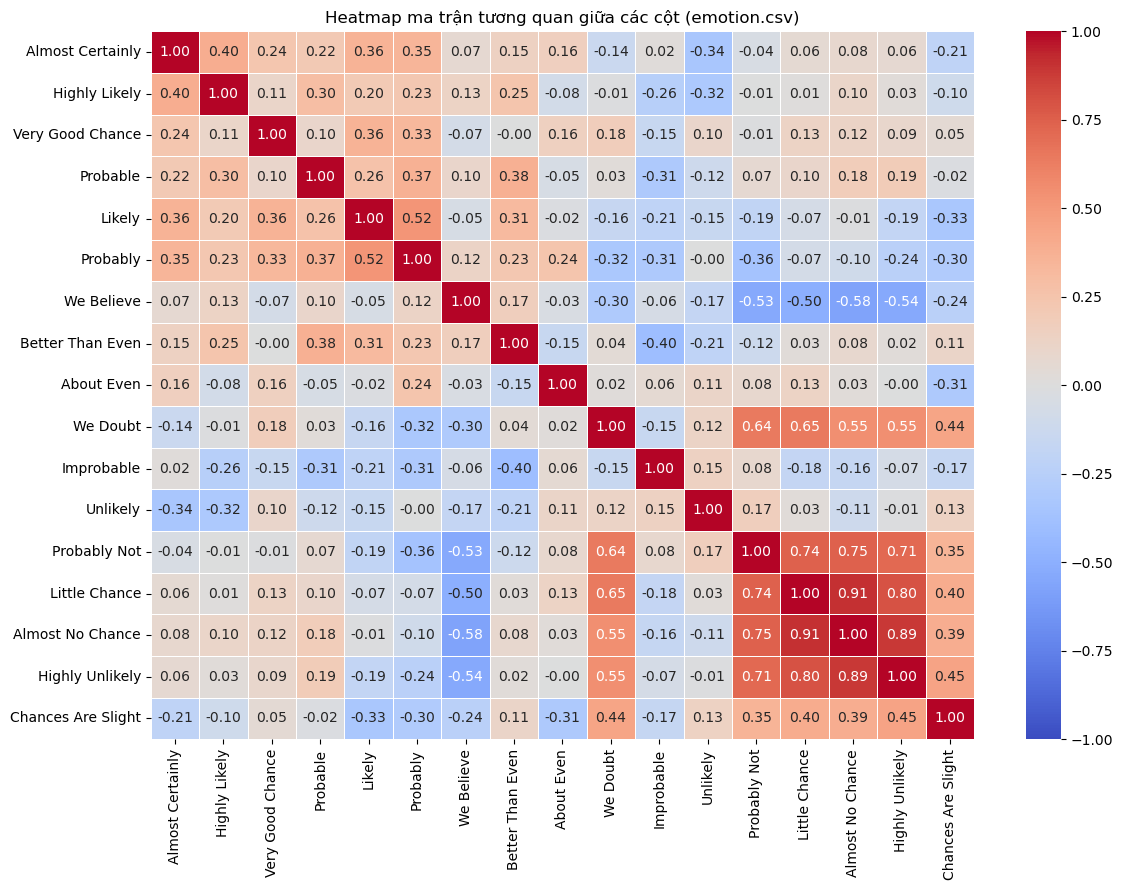

In [3]:

corr = df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap ma trận tương quan giữa các cột (emotion.csv)')
plt.tight_layout()
plt.show()

### Nhận xét - Bài 1

**Quan sát từ heatmap:**

- Các ô nằm trên đường chéo chính đều có giá trị **1.0** (màu đỏ đậm) — đây là tương quan của mỗi biến với chính nó.
- Nhiều cặp biến có **tương quan dương mạnh** (màu đỏ, giá trị gần 1): ví dụ các nhóm từ diễn đạt xác suất cao như *Almost Certainly*, *Highly Likely*, *Very Good Chance* thể hiện xu hướng tương đồng trong đánh giá.
- Ngược lại, các cặp biến như *Almost Certainly* với *Almost No Chance*, *Highly Unlikely* có **tương quan âm** (màu xanh, giá trị gần -1) — phản ánh đúng ý nghĩa ngữ nghĩa đối lập nhau.
- Nhóm các từ xác suất cao (*Probable*, *Likely*, *Probably*, *We Believe*) tương quan chặt chẽ với nhau → có thể được coi là một **cụm biến tương đồng**.
- Tương tự, nhóm xác suất thấp (*Little Chance*, *Almost No Chance*, *Highly Unlikely*) cũng hình thành **cụm tương quan dương** nội bộ, nhưng tương quan âm với nhóm xác suất cao.

**Kết luận:** Heatmap giúp xác nhận rằng bộ dữ liệu phản ánh thang đo xác suất ngôn ngữ tự nhiên — các từ có ý nghĩa gần nhau được đánh giá tương tự nhau, còn các từ đối lập nhau về mức độ xác suất có tương quan âm rõ ràng.

---
## Bài 2: Số lượng sản phẩm bán theo tháng - Tập dữ liệu `company_sales_data.csv`

In [4]:
df2 = pd.read_csv('dataset/company_sales_data.csv')
df2.head()

,month_number,facecream,facewash,toothpaste,bathingsoap,shampoo,moisturizer,total_units,total_profit
0,1,2500,1500,5200,9200,1200,1500,21100,211000
1,2,2630,1200,5100,6100,2100,1200,18330,183300
2,3,2140,1340,4550,9550,3550,1340,22470,224700
3,4,3400,1130,5870,8870,1870,1130,22270,222700
4,5,3600,1740,4560,7760,1560,1740,20960,209600


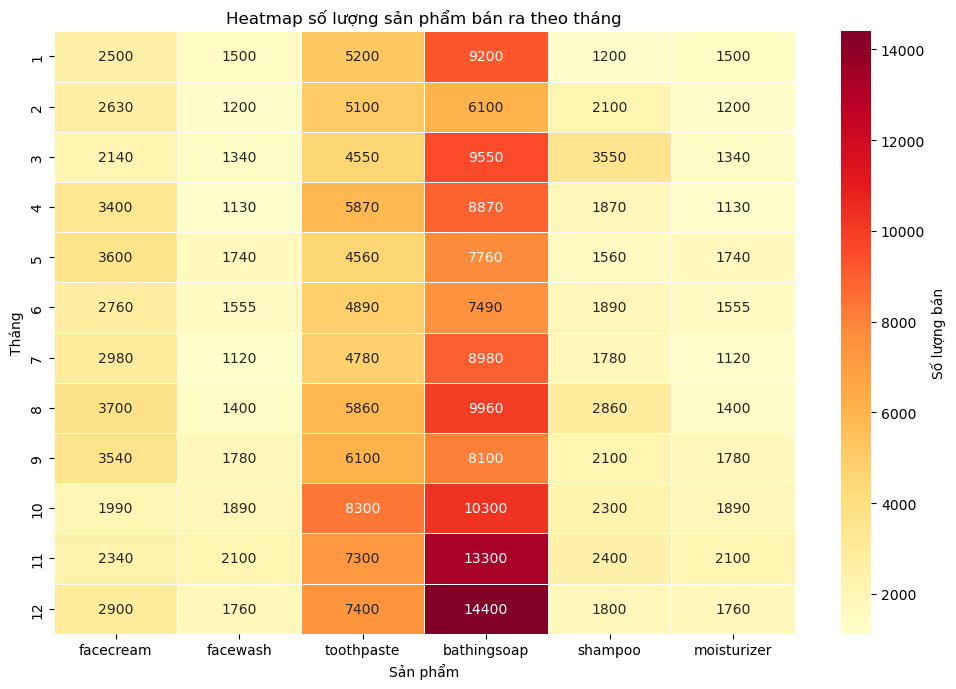

In [5]:
products = ['facecream', 'facewash', 'toothpaste', 'bathingsoap', 'shampoo', 'moisturizer']
data = df2.set_index('month_number')[products]

plt.figure(figsize=(10, 7))
sns.heatmap(data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Số lượng bán'})
plt.title('Heatmap số lượng sản phẩm bán ra theo tháng')
plt.xlabel('Sản phẩm')
plt.ylabel('Tháng')
plt.tight_layout()
plt.show()

### Nhận xét - Bài 2

**Quan sát từ heatmap:**

- **Bathing soap** (xà phòng tắm) có số lượng bán ra **cao nhất** trong hầu hết các tháng, đặc biệt nổi bật vào **tháng 11** (~13,300) và **tháng 12** (~14,400) — màu đỏ đậm nhất trên biểu đồ.
- **Toothpaste** (kem đánh răng) đứng thứ hai về doanh số, tăng rõ rệt vào **quý 4** (tháng 10–12), có thể do xu hướng mua sắm cuối năm.
- **Shampoo**, **facecream**, **facewash**, **moisturizer** có số lượng bán ra thấp hơn nhiều (màu vàng nhạt), tương đối ổn định qua các tháng.
- Nhìn theo hàng (theo tháng): **tháng 11 và tháng 12** là hai tháng có doanh số tổng thể cao nhất — hầu hết sản phẩm đều đậm màu hơn so với đầu năm.
- **Tháng 2** và **tháng 6** là các tháng có doanh số thấp nhất ở nhiều sản phẩm.

**Kết luận:** Heatmap cho thấy rõ sự chênh lệch lớn giữa các sản phẩm (bathing soap vượt trội) và xu hướng doanh số tăng vào cuối năm. Đây là thông tin hữu ích để doanh nghiệp lập kế hoạch nhập hàng và phân bổ ngân sách marketing theo mùa.